# CCF DNN Random-1000 Workflow

이 노트북은 `실제 FEMM 데이터 15개`를 학습 데이터로 사용하고, `랜덤 후보 1000개`는 DNN surrogate가 예측하도록 구성한 실습형 템플릿이다.

흐름은 다음과 같다.

1. 실제 FEMM 결과 15개 읽기
2. `3입력 4출력` DNN surrogate 학습
3. 설계변수 범위 안에서 랜덤 후보 1000개 생성
4. DNN이 1000개 후보의 성능을 예측
5. 평균토크-토크리플 산포도와 Pareto front 확인

주의: 현재 데이터 수가 매우 적기 때문에, 이 노트북은 surrogate 흐름을 익히는 용도에 더 가깝다.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Dense

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error

from pathlib import Path

np.random.seed(42)
tf.random.set_seed(42)

plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['axes.grid'] = True


In [2]:
csv_path = Path('/Users/dohyunkim/Documents/Window/femm_output_v_ipm_m19_axis_shortedge_ccf/axis_shortedge_ccf_summary.csv')
df = pd.read_csv(csv_path)

input_cols = [
    'magnet_thickness_mm',
    'magnet_length_mm',
    'v_angle_deg',
]

output_cols = [
    'loaded_torque_mean',
    'loaded_torque_ripple_pct',
    'cogging_torque_pkpk',
    'loaded_force_max',
]

data = df[input_cols + output_cols].copy()
data


,magnet_thickness_mm,magnet_length_mm,v_angle_deg,loaded_torque_mean,loaded_torque_ripple_pct,cogging_torque_pkpk,loaded_force_max
0,3,13.0,45.0,13.929401,37.830297,0.001604,1190.301253
1,3,13.0,60.0,24.586555,34.636739,0.006627,1203.567476
2,3,16.0,45.0,26.032086,31.696187,0.044483,1077.922839
3,3,16.0,60.0,40.168085,27.697272,0.185937,1087.528629
4,5,13.0,45.0,19.125020,43.202535,0.011596,1047.343322
5,5,13.0,60.0,31.987111,27.293634,0.008803,1032.068430
6,5,16.0,45.0,34.774458,35.369456,0.215795,1042.194010
7,5,16.0,60.0,50.729518,22.093547,0.378221,841.032027
8,3,14.5,52.5,26.903578,32.324188,0.016029,1123.411897
9,5,14.5,52.5,35.470886,25.685303,0.021345,1016.565695


## 1. 실제 학습 데이터와 예측 후보 데이터는 다르다

- 아래 `data`는 실제 FEMM 결과가 있는 데이터다.
- 이후 만들 `candidate_df`는 입력만 랜덤 생성한 후보점이다.
- 후보점 1000개의 출력은 FEMM이 아니라 DNN이 예측한다.


In [3]:
X = data[input_cols].to_numpy(dtype=float)
Y = data[output_cols].to_numpy(dtype=float)

print('number of measured FEMM samples =', len(X))
print('input shape =', X.shape)
print('output shape =', Y.shape)

display(data.describe())


number of measured FEMM samples = 15
input shape = (15, 3)
output shape = (15, 4)


,magnet_thickness_mm,magnet_length_mm,v_angle_deg,loaded_torque_mean,loaded_torque_ripple_pct,cogging_torque_pkpk,loaded_force_max
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,4.000000,14.500000,52.500000,30.651335,31.228849,0.080083,1062.270714
std,0.845154,1.267731,6.338657,9.460203,5.638348,0.108820,83.268065
min,3.000000,13.000000,45.000000,13.929401,22.093547,0.001604,841.032027
25%,3.000000,13.000000,45.000000,24.175458,27.418842,0.009523,1037.131220
50%,4.000000,14.500000,52.500000,31.651055,31.696187,0.021345,1066.776027
75%,5.000000,16.000000,60.000000,36.530916,35.003097,0.124802,1082.725734
max,5.000000,16.000000,60.000000,50.729518,43.202535,0.378221,1203.567476


In [4]:
scaler_input = MinMaxScaler()
scaler_output = MinMaxScaler()

X_scaled = scaler_input.fit_transform(X)
Y_scaled = scaler_output.fit_transform(Y)

X_train, X_valid, Y_train, Y_valid = train_test_split(
    X_scaled, Y_scaled, test_size=0.2, random_state=42
)

print('train size =', len(X_train))
print('valid size =', len(X_valid))


train size = 12
valid size = 3


In [5]:
class CCFSurrogate(Model):
    def __init__(self):
        super().__init__()
        self.hidden1 = Dense(64, activation='relu')
        self.hidden2 = Dense(64, activation='relu')
        self.hidden3 = Dense(32, activation='relu')
        self.out = Dense(4, activation='linear')

    def call(self, x):
        x = self.hidden1(x)
        x = self.hidden2(x)
        x = self.hidden3(x)
        return self.out(x)


model = CCFSurrogate()
model.compile(optimizer='adam', loss='mae', metrics=['mse'])

history = model.fit(
    X_train,
    Y_train,
    validation_data=(X_valid, Y_valid),
    epochs=300,
    batch_size=4,
    verbose=0,
)

pd.DataFrame(history.history).tail()


,loss,mse,val_loss,val_mse
295,0.005531,0.000055,0.100970,0.019180
296,0.004989,0.000040,0.096018,0.017334
297,0.005261,0.000049,0.097675,0.018501
298,0.005962,0.000051,0.098477,0.018722
299,0.006013,0.000061,0.095191,0.017631


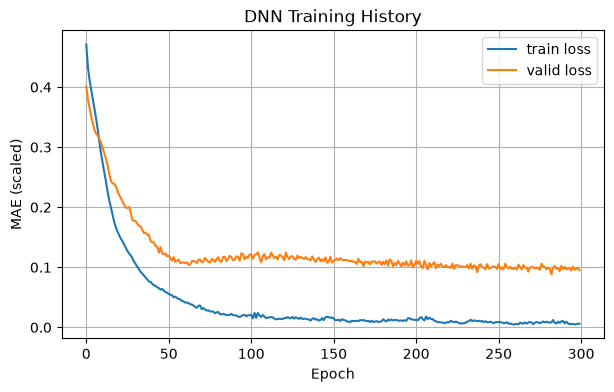

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history.history['loss'], label='train loss')
ax.plot(history.history['val_loss'], label='valid loss')
ax.set_title('DNN Training History')
ax.set_xlabel('Epoch')
ax.set_ylabel('MAE (scaled)')
ax.legend()
plt.show()


In [7]:
Y_pred_train = scaler_output.inverse_transform(model.predict(X_scaled, verbose=0))

metric_rows = []
for i, col in enumerate(output_cols):
    metric_rows.append({
        'output': col,
        'r2_on_measured_points': r2_score(Y[:, i], Y_pred_train[:, i]),
        'mae_on_measured_points': mean_absolute_error(Y[:, i], Y_pred_train[:, i]),
    })

metric_df = pd.DataFrame(metric_rows)
metric_df


,output,r2_on_measured_points,mae_on_measured_points
0,loaded_torque_mean,0.995447,0.317550
1,loaded_torque_ripple_pct,0.970544,0.319748
2,cogging_torque_pkpk,0.934097,0.012118
3,loaded_force_max,0.860427,12.860732


## 2. 랜덤 후보 1000개 만들기

여기서부터는 실제 FEMM을 1000번 돌리는 것이 아니라, 현재 15개가 가진 설계변수 범위 안에서 입력만 랜덤으로 생성한다.


In [8]:
n_candidates = 1000

bounds = pd.DataFrame({
    'min': data[input_cols].min(),
    'max': data[input_cols].max(),
})
display(bounds)

candidate_dict = {}
for col in input_cols:
    lo = bounds.loc[col, 'min']
    hi = bounds.loc[col, 'max']
    candidate_dict[col] = np.random.uniform(lo, hi, size=n_candidates)

candidate_df = pd.DataFrame(candidate_dict)
candidate_df.head()


,min,max
magnet_thickness_mm,3.0,5.0
magnet_length_mm,13.0,16.0
v_angle_deg,45.0,60.0


,magnet_thickness_mm,magnet_length_mm,v_angle_deg
0,3.749080,13.555399,48.925585
1,4.901429,14.625703,48.704682
2,4.463988,15.618838,58.593819
3,4.197317,15.196675,48.743193
4,3.312037,15.419683,49.079246


In [9]:
X_candidate_scaled = scaler_input.transform(candidate_df[input_cols])
Y_candidate_pred = scaler_output.inverse_transform(model.predict(X_candidate_scaled, verbose=0))

pred_df = candidate_df.copy()
for i, col in enumerate(output_cols):
    pred_df[col] = Y_candidate_pred[:, i]

pred_df.head()


/Users/dohyunkim/Documents/Window/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


,magnet_thickness_mm,magnet_length_mm,v_angle_deg,loaded_torque_mean,loaded_torque_ripple_pct,cogging_torque_pkpk,loaded_force_max
0,3.749080,13.555399,48.925585,21.511583,34.609123,-0.004112,1080.481567
1,4.901429,14.625703,48.704682,31.409201,33.785927,0.110794,1017.818665
2,4.463988,15.618838,58.593819,45.296665,23.718475,0.273658,923.067139
3,4.197317,15.196675,48.743193,31.645723,29.718830,0.116742,1028.136353
4,3.312037,15.419683,49.079246,29.112900,28.685764,0.050728,1067.983032


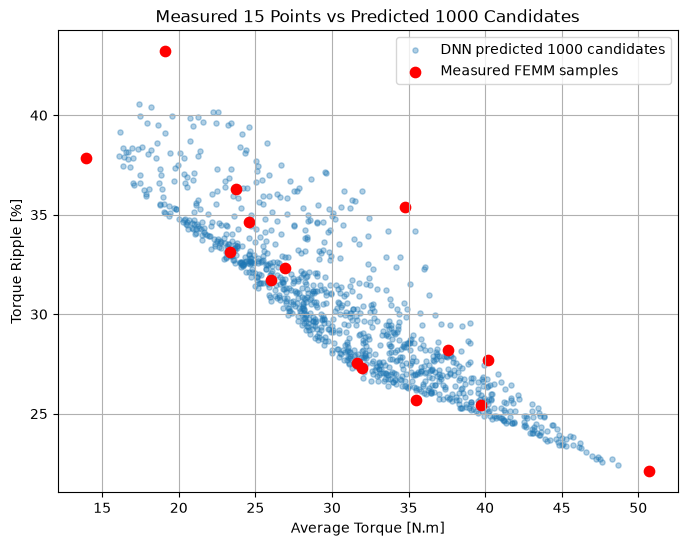

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    pred_df['loaded_torque_mean'],
    pred_df['loaded_torque_ripple_pct'],
    s=14,
    alpha=0.35,
    label='DNN predicted 1000 candidates',
)
ax.scatter(
    data['loaded_torque_mean'],
    data['loaded_torque_ripple_pct'],
    s=55,
    color='red',
    label='Measured FEMM samples',
)
ax.set_xlabel('Average Torque [N.m]')
ax.set_ylabel('Torque Ripple [%]')
ax.set_title('Measured 15 Points vs Predicted 1000 Candidates')
ax.legend()
plt.show()


In [11]:
def pareto_mask_max_torque_min_ripple(df_in):
    torque = df_in['loaded_torque_mean'].to_numpy()
    ripple = df_in['loaded_torque_ripple_pct'].to_numpy()
    is_pareto = np.ones(len(df_in), dtype=bool)

    for i in range(len(df_in)):
        if not is_pareto[i]:
            continue
        dominated = (
            (torque >= torque[i])
            & (ripple <= ripple[i])
            & ((torque > torque[i]) | (ripple < ripple[i]))
        )
        if dominated.any():
            is_pareto[i] = False

    return is_pareto


pred_df['is_pareto'] = pareto_mask_max_torque_min_ripple(pred_df)
pareto_df = pred_df[pred_df['is_pareto']].copy()
pareto_df = pareto_df.sort_values(
    ['loaded_torque_ripple_pct', 'loaded_torque_mean'],
    ascending=[True, False],
)

print('number of Pareto candidates =', len(pareto_df))
pareto_df.head(20)


number of Pareto candidates = 1


,magnet_thickness_mm,magnet_length_mm,v_angle_deg,loaded_torque_mean,loaded_torque_ripple_pct,cogging_torque_pkpk,loaded_force_max,is_pareto
427,4.775408,15.855435,59.338782,48.654678,22.426287,0.338246,871.171265,True


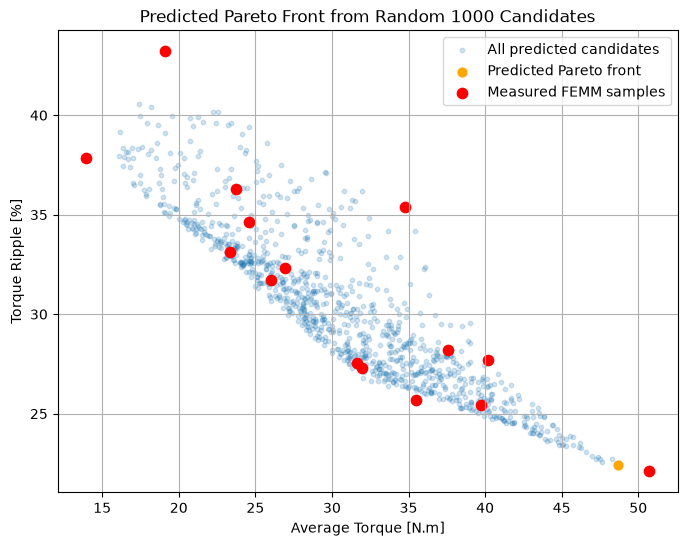

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    pred_df['loaded_torque_mean'],
    pred_df['loaded_torque_ripple_pct'],
    s=10,
    alpha=0.20,
    label='All predicted candidates',
)
ax.scatter(
    pareto_df['loaded_torque_mean'],
    pareto_df['loaded_torque_ripple_pct'],
    s=40,
    color='orange',
    label='Predicted Pareto front',
)
ax.scatter(
    data['loaded_torque_mean'],
    data['loaded_torque_ripple_pct'],
    s=55,
    color='red',
    label='Measured FEMM samples',
)
ax.set_xlabel('Average Torque [N.m]')
ax.set_ylabel('Torque Ripple [%]')
ax.set_title('Predicted Pareto Front from Random 1000 Candidates')
ax.legend()
plt.show()


In [13]:
top_cols = input_cols + output_cols + ['is_pareto']
pareto_df[top_cols].head(30)


,magnet_thickness_mm,magnet_length_mm,v_angle_deg,loaded_torque_mean,loaded_torque_ripple_pct,cogging_torque_pkpk,loaded_force_max,is_pareto
427,4.775408,15.855435,59.338782,48.654678,22.426287,0.338246,871.171265,True


## 3. 해석 포인트

- 이 노트북의 `1000개`는 실제 FEMM 결과가 아니라 surrogate prediction이다.
- 따라서 Pareto 후보는 바로 확정하지 말고, 상위 후보 몇 개를 다시 FEMM으로 재검증해야 한다.
- 현재 15개 데이터만으로는 surrogate가 과적합 또는 과신할 수 있으므로, 가능하면 30~50개 이상으로 실제 FEMM 데이터를 늘리는 것이 좋다.
- 이후에는 목적함수를 `-loaded_torque_mean`, `loaded_torque_ripple_pct`로 두고 NSGA-II로 확장할 수 있다.
